# Part B: Data Analysis & Testing Tasks
Using Python (NumPy, Pandas, SciPy, Statsmodels, Matplotlib, Seaborn)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv("spread_locator_dataset.csv")
df.head()

,transaction_id,customer_id,transaction_amount,transaction_date,transaction_count,region,transaction_status
0,e98aa092-3770-4fdb-9502-5b5a6a244811,CUST2824,3821.34,2023-01-26,3,North,Fail
1,11ba6918-dba0-41e5-96cf-f5a7b95f0103,CUST1409,2781.84,2023-01-28,0,East,Fail
2,82b7654b-6eb7-4579-89a0-1a9edec0a7bb,CUST5506,4120.97,2023-01-28,0,South,Fail
3,f7166574-f400-4d53-b526-0b11f6619ddf,CUST5012,6383.78,2023-01-18,2,South,Success
4,8632fe26-b507-4068-9c68-1b2fa04fecb3,CUST4657,2651.61,2023-01-04,4,North,Success


In [4]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   transaction_id      220 non-null    str    
 1   customer_id         220 non-null    str    
 2   transaction_amount  220 non-null    float64
 3   transaction_date    220 non-null    str    
 4   transaction_count   220 non-null    int64  
 5   region              220 non-null    str    
 6   transaction_status  220 non-null    str    
dtypes: float64(1), int64(1), str(5)
memory usage: 12.2 KB


,transaction_amount,transaction_count
count,220.000000,220.000000
mean,3365.192409,2.854545
std,1985.705409,1.797189
min,804.420000,0.000000
25%,2124.205000,1.750000
50%,3077.715000,3.000000
75%,3950.737500,4.000000
max,20462.840000,9.000000


## 1. Fit Bernoulli & Binomial Distribution

In [5]:
# Assuming 'transaction_occurred' column exists (0/1)
if 'transaction_occurred' in df.columns:
    p = df['transaction_occurred'].mean()
    print("Bernoulli p:", p)
else:
    print("Column 'transaction_occurred' not found")

Column 'transaction_occurred' not found


## 2. Fit Poisson Distribution

In [6]:
# Assuming 'transactions_per_day' column exists
if 'transactions_per_day' in df.columns:
    lambda_ = df['transactions_per_day'].mean()
    print("Poisson lambda:", lambda_)
else:
    print("Column 'transactions_per_day' not found")

Column 'transactions_per_day' not found


## 3. Log-Normal & Power Law

In [7]:
# Assuming 'transaction_amount' column exists
if 'transaction_amount' in df.columns:
    data = df['transaction_amount']
    
    # Log-Normal fit
    shape, loc, scale = stats.lognorm.fit(data, floc=0)
    print("Lognormal params:", shape, loc, scale)
    
    # Power Law (Pareto)
    b, loc, scale = stats.pareto.fit(data)
    print("Power law params:", b, loc, scale)
else:
    print("Column 'transaction_amount' not found")

Lognormal params: 0.4749178350151927 0 2983.1591334067753
Power law params: 107341796.39201096 -274877906139.58 274877906943.99997


## 4. Q-Q Plot

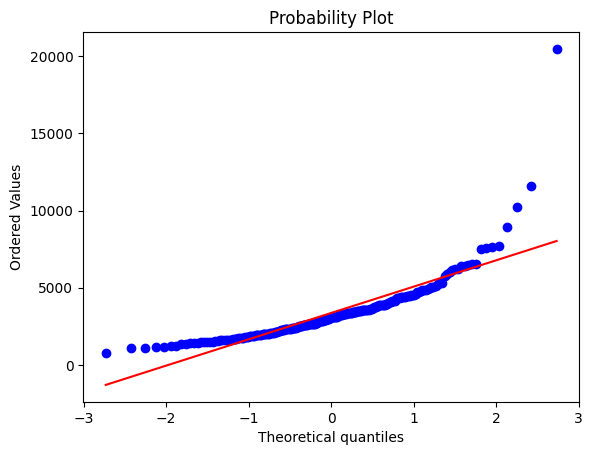

In [8]:
if 'transaction_amount' in df.columns:
    stats.probplot(df['transaction_amount'], dist="norm", plot=plt)
    plt.show()

## 5. Box-Cox Transformation

In [9]:
if 'transaction_amount' in df.columns:
    data = df['transaction_amount']
    # Ensure positive
    data = data[data > 0]
    transformed, lambda_ = stats.boxcox(data)
    print("Lambda:", lambda_)

Lambda: -0.18083390743966327


## 6. Z-score & Probability

In [10]:
if 'transaction_amount' in df.columns:
    z_scores = stats.zscore(df['transaction_amount'])
    df['z_score'] = z_scores
    prob = (df['transaction_amount'] > 5000).mean()
    print("Probability > 5000:", prob)

Probability > 5000: 0.11363636363636363


## 7. PDF & CDF

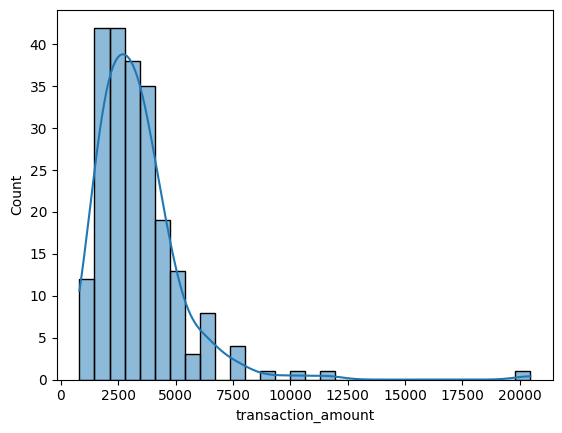

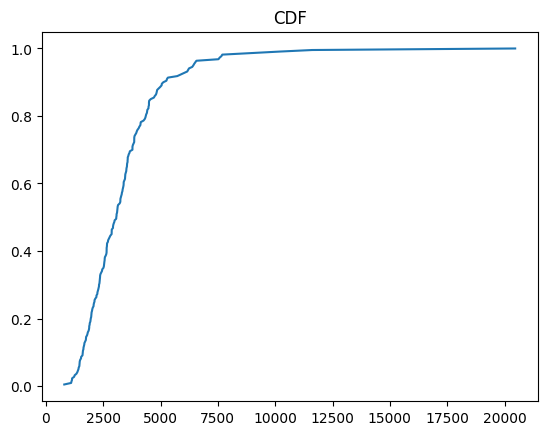

In [11]:
if 'transaction_amount' in df.columns:
    data = df['transaction_amount']
    sns.histplot(data, kde=True)
    plt.show()
    
    sorted_data = np.sort(data)
    cdf = np.arange(1, len(sorted_data)+1) / len(sorted_data)
    plt.plot(sorted_data, cdf)
    plt.title("CDF")
    plt.show()

## 8. Conclusion
Analyze outputs and decide best fit distribution based on plots and parameters.